In [2]:
# Logistic Regression 
import os 
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [3]:
current_dir = Path.cwd()  
PROJECT_ROOT = current_dir.parent.parent

df = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'Cleaned_csv.csv')

df = df.drop(labels=['Unnamed: 0'], axis=1)
df = df.rename(columns=lambda x: x.replace('remainder__', ''))
df.head()

,encoder__City_Los Angeles,encoder__City_Other,encoder__City_San Diego,encoder__City_San Francisco,encoder__Gender_Female,encoder__Gender_Male,encoder__Senior Citizen_No,encoder__Senior Citizen_Yes,encoder__Dependents_No,encoder__Dependents_Yes,...,encoder__Paperless Billing_Yes,encoder__Payment Method_Bank transfer (automatic),encoder__Payment Method_Credit card (automatic),encoder__Payment Method_Electronic check,encoder__Payment Method_Mailed check,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,2.0,53.85,108.15,1.0,3239.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,2.0,70.70,151.65,1.0,2701.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,8.0,99.65,820.50,1.0,5372.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,28.0,104.80,3046.05,1.0,5003.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,49.0,103.70,5036.30,1.0,5340.0


In [4]:
# Train test split 

X = df.drop(labels=['Churn Value'], axis=1)
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating Pipeline 

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression())
])

# Fitting the model 

pipeline.fit(X_train, y_train)

# Evaluate 

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1: {f1:.3f}')

Accuracy: 0.754
Recall: 0.797
F1: 0.648


C:\Users\andre\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# Applying GridsearchCV 

params_lbfgs = {
    'model__penalty': ['l2', None],
    'model__solver': ['lbfgs'],
    'model__C': [0.2, 0.4, 0.6, 0.8, 1, 1.2]
}

params_liblinear = {
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__C': [0.2, 0.4, 0.6, 0.8, 1, 1.2]
}

params_saga = {
    'model__penalty': ['l1', 'l2', 'elasticnet'],
    'model__solver': ['saga'],
    'model__C': [0.2, 0.4, 0.6, 0.8, 1, 1.2],
    'model__l1_ratio': [0.5] 
}

params_grid = [params_lbfgs, params_liblinear, params_saga]

grid_search = GridSearchCV(
    pipeline,
    params_grid,
    cv=5,
    scoring='recall',  
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'model__C': 0.4, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

In [6]:
y_pred = grid_search.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1: {f1:.3f}')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.751
Recall: 0.807
F1: 0.648
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1009
         1.0       0.54      0.81      0.65       400

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.80      0.75      0.76      1409

[[735 274]
 [ 77 323]]


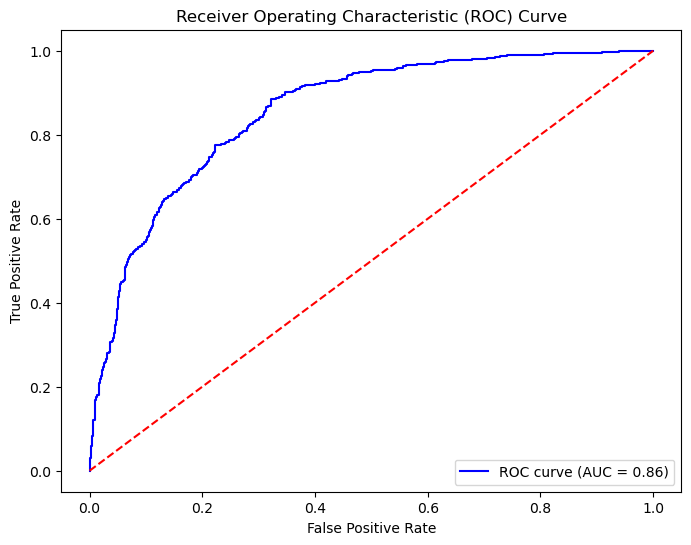

In [7]:
# Getting the ROC_AUC Curve
best_model = grid_search.best_estimator_

y_probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

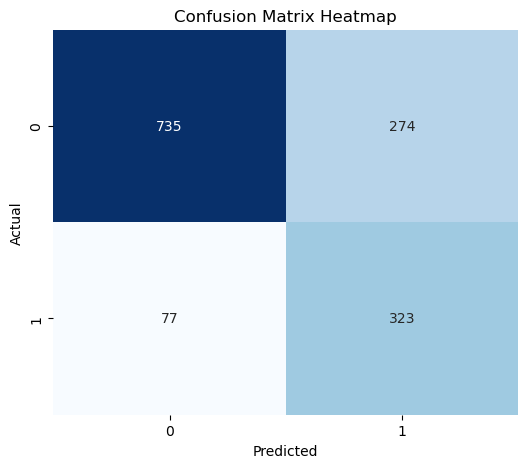

In [8]:
cm = np.array([[735, 274],
               [77, 323]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [10]:
# Storing into dataframe 

models_df = pd.DataFrame({
    'Model': ['Baseline Model (Logistic Regression)'],
    'Accuracy': [round(accuracy, 3)],
    'Recall': [round(recall, 3)],
    'F1':[round(f1,3)]
})

models_df.to_csv(PROJECT_ROOT/'data'/'processed'/'model_results.csv', index=False, mode='w')